# Final Wrap-up

최종 summary table과 세 개의 wrap-up figure를 한 번에 정리하는 notebook입니다.
필요하면 window, seed subset, legend를 이 notebook 안에서 바로 바꾸면 됩니다.


In [1]:
from pathlib import Path
import sys

def find_final_code_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "final_wrapup_manifest.yaml").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate final_code root from the current working directory.")

FINAL_CODE_ROOT = find_final_code_root(Path.cwd().resolve())
NOTEBOOK_ROOT = FINAL_CODE_ROOT / "notebooks"
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from _shared.final_wrapup import (
    build_classification_table,
    build_main_results_table,
    build_operator_table,
    build_time_series_table,
    export_results_summary,
    final_code_root,
    inventory_frame,
    load_manifest,
    plot_final_classification,
    plot_final_operator,
    plot_final_time_series,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

FINAL_CODE_ROOT


PosixPath('/home/namkyeong/ssmo/final_code')

In [2]:
SEED_OVERRIDES = {}

TIME_WINDOWS = {
    "etth1": (1, 20),
    "weather": (1, 20),
    "electricity": (1, 20),
}
OPERATOR_WINDOWS = {
    "burgers": (120, 180),
    "darcy": (110, 150),
}
OPERATOR_FULL_WINDOWS = {
    "burgers": (1, 180),
    "darcy": (1, 150),
}
CLASS_WINDOWS = {
    "cifar10": (1, 100),
    "cifar100": (1, 50),
}
CLASS_TAIL_WINDOWS = {
    "cifar10": (84, 100),
    "cifar100": (40, 50),
}
LEGEND_LABELS = {
    "independent": "Independent",
    "dml": "DML",
    "ssml": "SSML",
}

SHOW_BANDS = False
EXPORT_TABLE = True
EXPORT_FIGURES = True
EXPORT_RESULTS_SUMMARY = True


In [3]:
final_table = build_main_results_table(seed_overrides=SEED_OVERRIDES, export=EXPORT_TABLE)
display(final_table)


,Task,Dataset,Note,Independent,DML,SSML
0,Time-series,ETTh1,"Independent/DML 6 seeds, SSML 3 seeds, best_br...",0.2720 ± 0.0004,0.3210 ± 0.0086,0.2718 ± 0.0005
1,Time-series,Weather,"3 seeds, lower is better",0.2735 ± 0.0086,0.2841 ± 0.0018,0.2602 ± 0.0030
2,Time-series,Electricity,best checkpoint reading,0.1524 ± 0.0001,0.1644 ± 0.0011,0.1005 ± 0.0009
3,Operator,Burgers,same-campaign independent vs SSML,1.01e-06 ± 3.28e-07,8.91e-06 ± 2.15e-06,9.72e-07 ± 2.97e-07
4,Operator,Darcy,"same-track independent, DML, SSML",0.003230 ± 0.000658,0.005073 ± 0.000902,0.003212 ± 0.000645
5,Classification,CIFAR-10,"acc1 (%), higher is better",85.34 ± 0.18,84.82 ± 0.07,86.18 ± 0.09
6,Classification,CIFAR-100,cifarstem follow-up row,47.38 ± 1.06,53.03 ± 1.57,53.13 ± 1.56


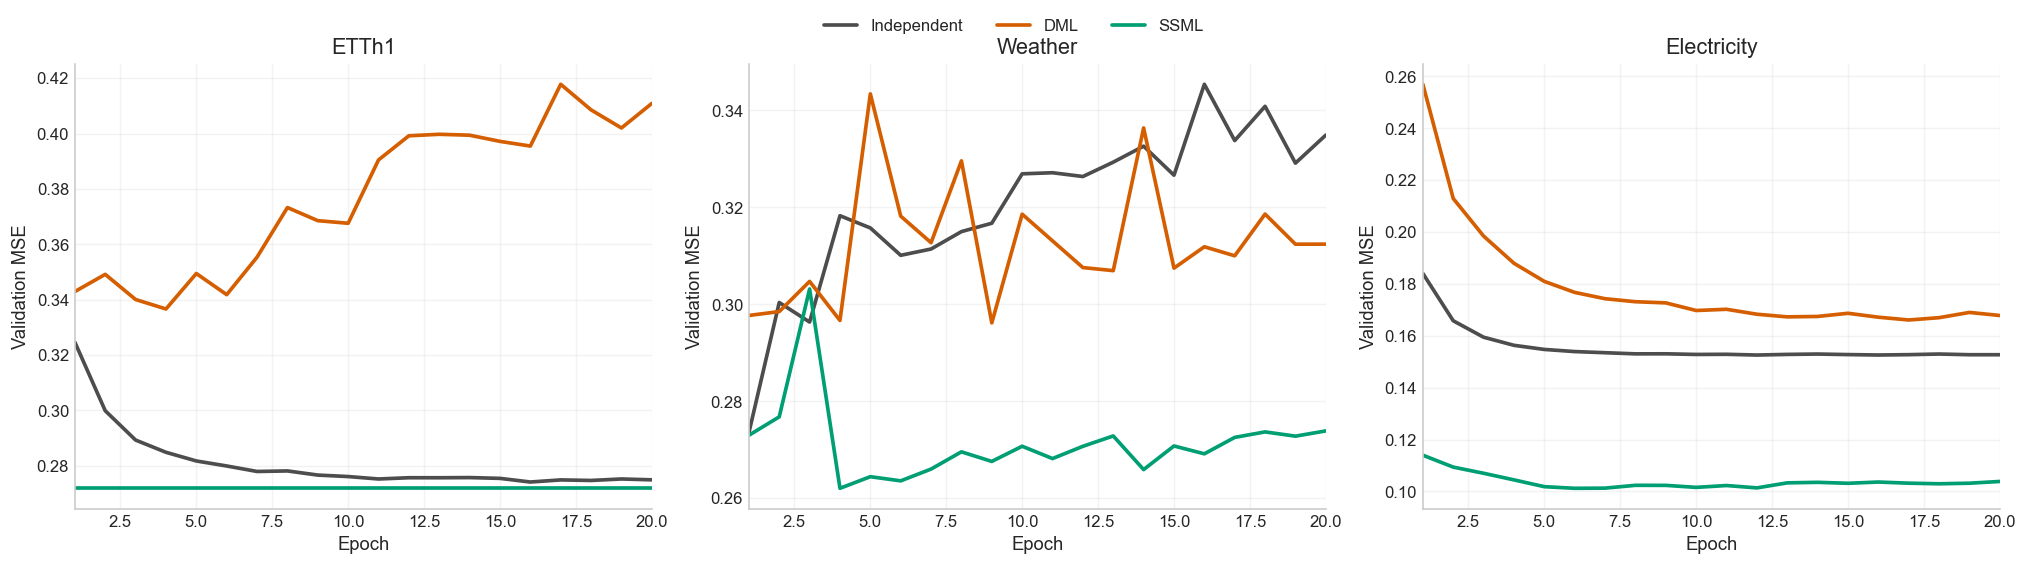

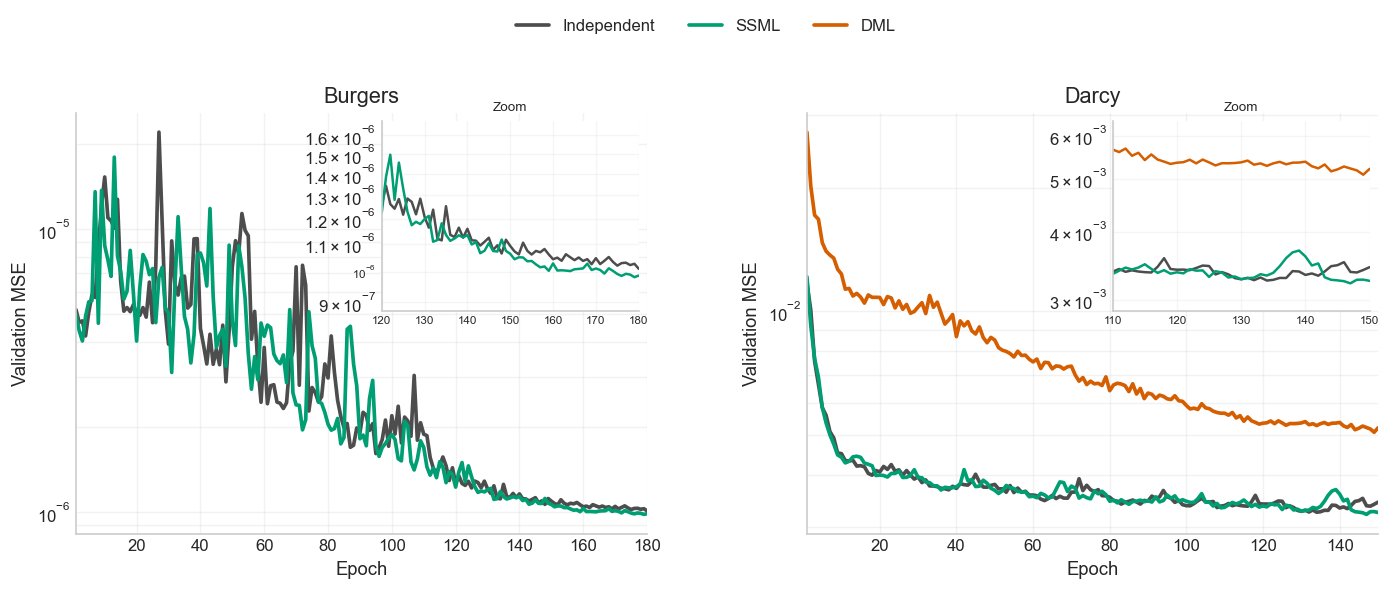

/home/namkyeong/ssmo/final_code/notebooks/_shared/final_wrapup.py:844: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


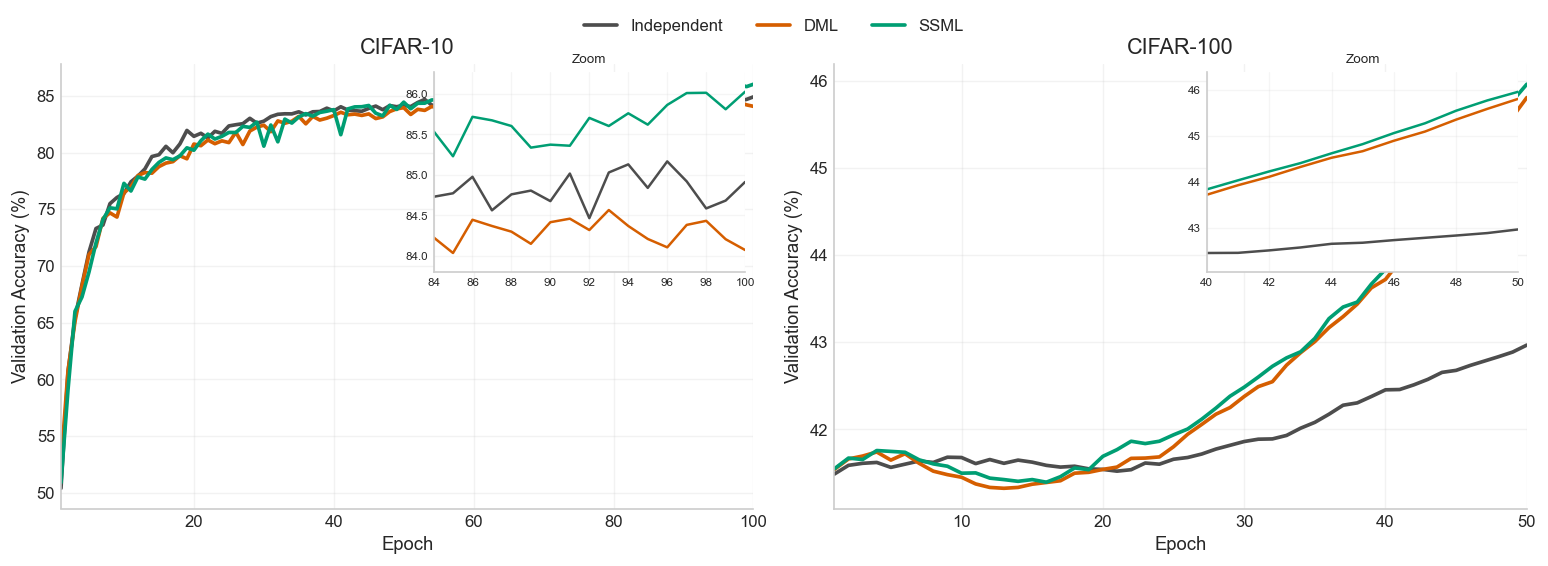

In [4]:
fig_time = plot_final_time_series(
    seed_overrides=SEED_OVERRIDES,
    windows=TIME_WINDOWS,
    legend_labels=LEGEND_LABELS,
    show_bands=SHOW_BANDS,
    export=EXPORT_FIGURES,
)
plt.show()

fig_operator = plot_final_operator(
    seed_overrides=SEED_OVERRIDES,
    windows=OPERATOR_WINDOWS,
    full_windows=OPERATOR_FULL_WINDOWS,
    legend_labels=LEGEND_LABELS,
    show_bands=SHOW_BANDS,
    export=EXPORT_FIGURES,
)
plt.show()

fig_classification = plot_final_classification(
    seed_overrides=SEED_OVERRIDES,
    windows=CLASS_WINDOWS,
    tail_windows=CLASS_TAIL_WINDOWS,
    legend_labels=LEGEND_LABELS,
    show_bands=SHOW_BANDS,
    export=EXPORT_FIGURES,
)
plt.show()


In [5]:
if EXPORT_RESULTS_SUMMARY:
    summary_path = export_results_summary()
    display(Markdown(f"Results summary exported: `{summary_path.relative_to(FINAL_CODE_ROOT)}`"))


Results summary exported: `Results_Summary.md`